In [1]:
%load_ext autoreload

from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")

True

In [2]:
%autoreload 2

import json
import random
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
ca = gpd.read_file("/Volumes/x10pro/estuary/geos/ca_geo.geojson")
pmep_points = gpd.read_file("/Volumes/x10pro/estuary/geos/PMEP_Estuary_Points_V1_3.gdb/").to_crs(
    ca.crs
)

# Goleta Slough too close to San Pedro Creek, we see both!
pmep_points = pmep_points[pmep_points.PMEP_EstuaryID != 4003].copy()


def read_grid(p):
    gdf = gpd.read_file(p).to_crs(ca.crs)
    gdf["Site code"] = int(p.stem)
    return gdf


grids = gpd.GeoDataFrame(
    pd.concat(
        [read_grid(p) for p in Path("/Volumes/x10pro/estuary/ca_grids/").glob("*.geojson")],
        ignore_index=True,
    ),
    geometry="geometry",
).to_crs(ca.crs)
grids["skipped"] = False

skipped_grids = gpd.GeoDataFrame(
    pd.concat(
        [read_grid(p) for p in Path("/Volumes/x10pro/estuary/skipped_grids/").glob("*.geojson")],
        ignore_index=True,
    ),
    geometry="geometry",
).to_crs(ca.crs)
skipped_grids["skipped"] = True

grids = gpd.GeoDataFrame(
    pd.concat([grids, skipped_grids], ignore_index=True), geometry="geometry"
).to_crs(ca.crs)

pmep_points = pmep_points[pmep_points.intersects(ca.iloc[0].geometry)].copy()

/Users/kyledorman/Documents/UCLA_kelp/estuary/.venv/lib/python3.12/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


In [4]:
grids.head(5)

,Site code,Site name,geometry,skipped
0,16,Las Fores Creek,"POLYGON ((-117.45996 33.28668, -117.46 33.2940...",False
1,64,Tunitas Creek,"POLYGON ((-122.39691 37.35474, -122.39686 37.3...",False
2,39,Van Gordon Creek,"POLYGON ((-121.12303 35.59242, -121.12287 35.5...",False
3,29,NaN,"POLYGON ((-119.65962 34.41434, -119.65979 34.4...",False
4,52,None,"POLYGON ((-122.07403 36.95069, -122.07396 36.9...",False


In [5]:
# Example: pick something appropriate for your region, like a UTM zone
gdf_pts = pmep_points.to_crs("EPSG:32610")  # just an example
gdf_grid = grids.to_crs(gdf_pts.crs)

gdf_pts["name_norm"] = gdf_pts["Estuary_Name"].str.lower().str.strip()
gdf_grid["name_norm"] = gdf_grid["Site name"].str.lower().str.strip()

name_join = gdf_pts.merge(
    gdf_grid,  # include other grid columns if needed
    on="name_norm",
    how="left",
    suffixes=("", "_grid"),
    right_index=False,
)

matched_by_name = name_join[~name_join["geometry_grid"].isna()].copy()
unmatched_pts = (
    name_join[name_join["geometry_grid"].isna()]
    .copy()
    .drop(columns=["Site code", "Site name", "skipped", "geometry_grid"])
)

# Left join: keep all points, attach polygon attrs where they intersect
pts_with_grid = gpd.sjoin(
    unmatched_pts,
    gdf_grid.drop(columns=["name_norm"]),
    how="left",
    predicate="intersects",
).drop(columns=["index_right"])

len(matched_by_name), (~pts_with_grid["Site code"].isna()).sum(), len(gdf_grid)

(40, 20, 90)

In [6]:
no_grid_pts = (
    pts_with_grid[pts_with_grid["Site code"].isna()]
    .copy()
    .drop(columns=["Site code", "Site name", "skipped"])
)

N = 1500  # meters

grid_buffer = gdf_grid.copy()
grid_buffer["geometry"] = grid_buffer.buffer(N)

near_pts = gpd.sjoin(
    no_grid_pts.drop(columns=["name_norm"]),
    grid_buffer.drop(columns=["name_norm"]),
    how="inner",
    predicate="intersects",
).drop(columns=["index_right"])

len(near_pts)

25

In [7]:
m = gdf_grid.explore(style_kwds={"fillOpacity": 0, "color": "black"})
near_pts.explore(m=m, marker_kwds={"radius": 6})

In [8]:
remove = [4048, 4041, 4011, 4008, 4006, 3096, 3073, 3074, 3071, 3067, 3043, 3027, 3025]

# remove = [4048, 4011, 4006, 4008, 3073, 3074, 3071, 3067, 3025, 3027, 3043, 3096, 4041, 4014, 3096, 3089, 3076, 3073, 3065, 3010]

In [9]:
near_pts = near_pts[~near_pts.PMEP_EstuaryID.isin(remove)].copy()
intersect_points = pts_with_grid[~pts_with_grid["Site code"].isna()].copy()
matches = gpd.GeoDataFrame(
    pd.concat(
        [
            near_pts,
            intersect_points.drop(columns=["name_norm"]),
            matched_by_name.drop(columns=["name_norm", "geometry_grid"]),
        ]
    ),
    geometry="geometry",
    crs=intersect_points.crs,
)
matches["skipped"] = matches.skipped.apply(bool)
print(len(matches))
matches.head()

70


,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,geometry,Site code,Site name,skipped
24,3001,Mattole River,PMEP,Lagoonal Estuary,Central California,145.0,167.631360,3001_Mattole River,POINT Z (385741.752 4461034.456 0.0001),92.0,Mattolle River,False
60,3037,Estero de San Antonio,PMEP,Lagoonal Estuary,Central California,178.0,86.407162,3037_Estero de San Antonio,POINT Z (503478.988 4235422.935 0.0001),67.0,Estereo De San Antonio,False
81,3059,Pescadero Creek,PMEP,Lagoonal Estuary,Central California,195.0,129.097204,3059_Pescadero Creek,POINT Z (552788.123 4124009.819 0.0001),2138.0,Pescadero estuary,False
84,3062,Waddell Creek,PMEP,Lagoonal Estuary,Central California,198.0,16.856975,3062_Waddell Creek,POINT Z (564247.565 4106017.739 0.0001),63.0,NaN,False
99,3077,Pajaro River,PMEP,Lagoonal Estuary,Central California,213.0,367.656781,3077_Pajaro River,POINT Z (605909.659 4079908.969 0.0001),51.0,NaN,False


In [10]:
matched_valid = matches["Site code"].unique().astype(int)
print(len(matched_valid), sum(~gdf_grid.skipped))

gdf_grid[(~gdf_grid["Site code"].isin(matched_valid)) & (gdf_grid.skipped == False)]

69 72


,Site code,Site name,geometry,skipped,name_norm
14,65,Abbots Lagoon,"POLYGON ((504266.278 4218368.05, 504266.278 42...",False,abbots lagoon
31,66,NaN,"POLYGON ((504661.908 4222637.898, 504661.908 4...",False,NaN
41,37,None,"POLYGON ((693416.498 3920558.649, 693416.498 3...",False,None
42,55,Rio Del Mar,"POLYGON ((599176.76 4090511.669, 599176.76 409...",False,rio del mar


In [11]:
missed_grids = gdf_grid[~gdf_grid["Site code"].isin(matches["Site code"])]

m = gdf_pts[~gdf_pts.PMEP_EstuaryID.isin(matches.PMEP_EstuaryID)].explore(marker_kwds={"radius": 6})
missed_grids[missed_grids.skipped == False].explore(
    m=m, style_kwds={"fillOpacity": 0, "color": "black"}
)

<Axes: >

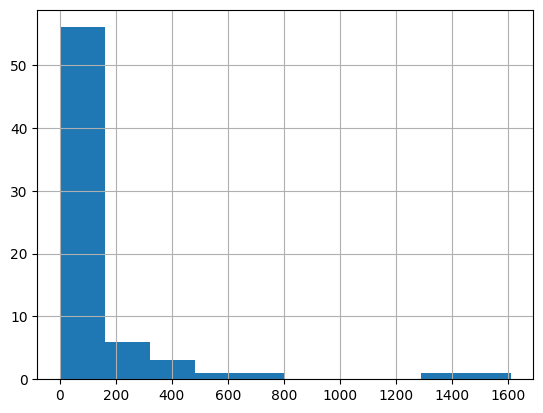

In [12]:
valid_matches = matches[matches.skipped == False]
valid_matches.Estuary_Hectares.hist()

In [13]:
valid_matches[valid_matches.Estuary_Hectares < 5]

,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,geometry,Site code,Site name,skipped
91,3069,Younger Lagoon,PMEP,Lagoonal Estuary,Central California,205.0,2.641736,3069_Younger Lagoon,POINT Z (583100.033 4089808.004 0.0001),53.0,Younder Lagoon,False
109,3087,Arroyo Laguna,PMEP,Lagoonal Estuary,Central California,223.0,1.126847,3087_Arroyo Laguna,POINT Z (661177.811 3946840.706 0.0001),41.0,NaN,False
130,4001,Bell Canyon Creek,PMEP,Lagoonal Estuary,Southern California Bight,244.0,1.120731,4001_Bell Canyon Creek,POINT Z (783702.377 3814139.772 0.0001),26.0,Bell Canyon,False
133,4005,Mission Creek Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,248.0,3.468035,4005_Mission Creek Lagoon,POINT Z (804586.136 3812946.157 0.0001),27.0,Mission Creek,False
146,4018,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,POINT Z (886019.981 3771655.045 0.0001),18.0,Zuma Lagoon,False
168,4040,San Mateo Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,283.0,4.324525,4040_San Mateo Lagoon,POINT Z (1003226.695 3707373.179 0.0001),17.0,San Mateo Creek,False
171,4043,Las Flores Creek,PMEP,Lagoonal Estuary,Southern California Bight,286.0,3.484179,4043_Las Flores Creek,POINT Z (1015834.528 3697169.003 0.0001),16.0,Las Fores Creek,False
27,3004,Cottaneva Creek,PMEP,Lagoonal Estuary,Central California,148.0,3.205450,3004_Cottaneva Creek,POINT Z (429084.484 4398668.811 0.0001),87.0,Cottaneva Creek,False
55,3032,Russian Gulch Creek,PMEP,Lagoonal Estuary,Central California,173.0,4.029889,3032_Russian Gulch Creek,POINT Z (486449.31 4257764.931 0.0001),73.0,Russian Gulch Creek,False
73,3051,San Pedro Creek,PMEP,Lagoonal Estuary,Central California,188.0,0.618619,3051_San Pedro Creek,POINT Z (543684.083 4161075.457 0.0001),28.0,San Pedro Creek,False


<Axes: >

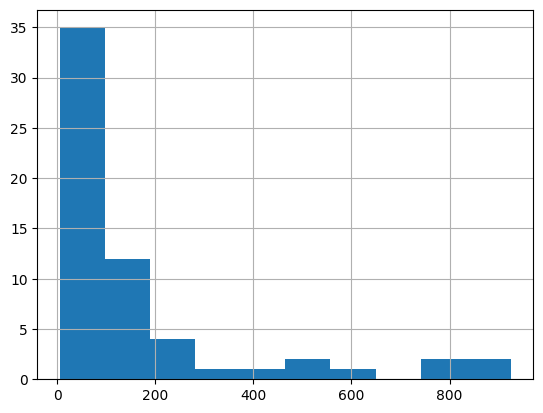

In [14]:
unmatched_pts = gdf_pts[~gdf_pts.PMEP_EstuaryID.isin(matches.PMEP_EstuaryID)]
unmatched_pts[
    (unmatched_pts.Estuary_Hectares < 1000) & (unmatched_pts.Estuary_Hectares > 5)
].Estuary_Hectares.hist()

In [15]:
potentials = unmatched_pts[
    (unmatched_pts.Estuary_Hectares > 5) & (unmatched_pts.CMECS_Class == "Lagoonal Estuary")
]

print(len(potentials))

potentials.explore(marker_kwds={"radius": 6})

27


In [16]:
maybe_add = [2097, 2096, 2103, 2105, 3008, 3009, 3028, 3027, 3057, 3073, 3099, 4054]

sorted(potentials[potentials.PMEP_EstuaryID.isin(maybe_add)].Estuary_Name.tolist())

['Brush Creek',
 'Corcoran Lagoon',
 'Fern Canyon',
 'Inglenook Fen',
 'Little River',
 'Mad River',
 'Manchester',
 'Ossagon Creek',
 'San Elijo Lagoon',
 'San Gregorio Creek',
 'San Luis Obispo Creek Lagoon',
 'Ten Mile River']

In [17]:
grids_data = (
    gpd.read_file("/Volumes/x10pro/estuary/geos/ca_data.geojson")
    .drop(columns=["Nation", "Region", "Studied (1) / Not Studied (0)", "Longitude", "Latitude"])
    .set_index("Site code")
    .to_crs(ca.crs)
    .rename(columns={"geometry": "point_geom"})
    .join(grids.set_index("Site code").drop(columns=["Site name"]), how="inner")
)
grids_data.head()

,Site name,point_geom,geometry,skipped
Site code,,,,
11,Los Penasquitos Lagoon,POINT (-117.26 32.933),"POLYGON ((-117.25816 32.93218, -117.25817 32.9...",False
12,Buena Vista Lagoon,POINT (-117.358 33.166),"POLYGON ((-117.35532 33.16208, -117.35535 33.1...",False
13,Lorna Alta Creek,POINT (-117.369 33.177),"POLYGON ((-117.36543 33.17464, -117.36546 33.1...",True
14,San Luis Rey River,POINT (-117.391 33.203),"POLYGON ((-117.38623 33.19826, -117.38627 33.2...",False
15,Santa Margarita River,POINT (-117.416 33.231),"POLYGON ((-117.40524 33.22463, -117.4053 33.23...",False


In [18]:
matches["Site code"] = matches["Site code"].astype(int)
pmep_merged = grids_data.join(
    matches.set_index("Site code")
    .to_crs(ca.crs)
    .rename(columns={"geometry": "pmep_pt_geom"})
    .drop(columns=["Site name", "skipped"]),
    how="left",
)
pmep_merged["potential_add"] = False
pmep_merged.PMEP_EstuaryID.isna().sum()

21

In [19]:
pmep_merged.head(1)

,Site name,point_geom,geometry,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,pmep_pt_geom,potential_add
Site code,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,POINT (-117.26 32.933),"POLYGON ((-117.25816 32.93218, -117.25817 32.9...",False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,POINT Z (-117.25671 32.93154 0.00013),False


In [20]:
to_add = potentials[potentials.PMEP_EstuaryID.isin(maybe_add)].copy().to_crs(pmep_merged.crs)
to_add["potential_add"] = True
to_add["Site code"] = to_add.PMEP_EstuaryID + 10000
to_add["Site name"] = to_add.Estuary_Name
to_add["point_geom"] = to_add.geometry
to_add["pmep_pt_geom"] = to_add.geometry
to_add["skipped"] = False
to_add = to_add.set_index("Site code").drop(columns=["name_norm"])

pmep_merged_with_extra = pd.concat([pmep_merged, to_add])

pmep_merged_with_extra.head(3)

,Site name,point_geom,geometry,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,pmep_pt_geom,potential_add
Site code,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,POINT (-117.26 32.933),"POLYGON ((-117.25816 32.93218, -117.25817 32.9...",False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,POINT Z (-117.25671 32.93154 0.00013),False
12,Buena Vista Lagoon,POINT (-117.358 33.166),"POLYGON ((-117.35532 33.16208, -117.35535 33.1...",False,4051.0,Buena Vista Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,294.0,94.294045,4051_Buena Vista Lagoon,POINT Z (-117.35134 33.17241 0.00013),False
13,Lorna Alta Creek,POINT (-117.369 33.177),"POLYGON ((-117.36543 33.17464, -117.36546 33.1...",True,4050.0,Loma Alta Marsh,PMEP,Lagoonal Estuary,Southern California Bight,293.0,1.628772,4050_Loma Alta Marsh,POINT Z (-117.36819 33.17823 0.00013),False


In [21]:
df = pd.read_csv("/Volumes/x10pro/estuary/ca_all/empa/grab_events.csv")
df = df[(df.latitude > -87) & (df.longitude < 100)].drop_duplicates(["siteid"])
df = df[["siteid", "estuaryname", "latitude", "longitude"]]
import geopandas as gpd

empa_sites = (
    gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
        crs="EPSG:4326",
    )
    .drop(columns=["latitude", "longitude"])
    .sort_values("siteid")
    .reset_index(drop=True)
)
empa_sites["name_norm"] = empa_sites["estuaryname"].str.lower().str.strip()
empa_sites.head()
# gdf.explore(marker_kwds={"radius": 6, 'color': 'blue'})

,siteid,estuaryname,geometry,name_norm
0,Baja-PB,Estero Punta Banda,POINT (-116.62267 31.75105),estero punta banda
1,Baja-SQ,Bahia de San Quintin,POINT (-116.02548 30.45127),bahia de san quintin
2,CC-ADLC,Arroyo de la Cruz,POINT (-121.30957 35.70992),arroyo de la cruz
3,CC-CAR,Carmel River,POINT (-121.92667 36.53992),carmel river
4,CC-ELK,Elkhorn Slough,POINT (-121.77862 36.8148),elkhorn slough


In [22]:
# empa_sites = gpd.read_file("/Volumes/x10pro/estuary/geos/empa_sites.geojson").to_crs(ca.crs)
# empa_sites["name_norm"] = empa_sites["estuaryname"].str.lower().str.strip()
# empa_sites.head()

In [23]:
aaa = pmep_merged_with_extra.reset_index()
aaa["name_norm"] = aaa["Site name"].str.lower().str.strip()

name_join = aaa.merge(
    empa_sites.drop_duplicates(["siteid", "estuaryname"])[["name_norm", "siteid"]],
    on="name_norm",
    how="left",
    right_index=False,
)
name_match = name_join[~name_join.siteid.isna()].copy()
name_miss = name_join[name_join.siteid.isna()].drop(columns=["siteid"])
name_miss["name_norm"] = name_miss["Estuary_Name"].str.lower().str.strip()

name_join2 = name_miss.merge(
    empa_sites.drop_duplicates(["siteid", "estuaryname"])[["name_norm", "siteid"]],
    on="name_norm",
    how="left",
    right_index=False,
)

pmep_empa_name_merged = (
    pd.concat([name_match, name_join2], ignore_index=True)
    .set_index("Site code")
    .drop(columns=["name_norm"])
)

pmep_empa_name_merged.head()

,Site name,point_geom,geometry,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,pmep_pt_geom,potential_add,siteid
Site code,,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,POINT (-117.26 32.933),"POLYGON ((-117.25816 32.93218, -117.25817 32.9...",False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,POINT Z (-117.25671 32.93154 0.00013),False,SC-LPL
18,Zuma Lagoon,POINT (-118.821 34.015),"POLYGON ((-118.81685 34.01177, -118.81699 34.0...",False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,POINT Z (-118.82062 34.01456 0.00013),False,SC-ZUM
21,Ventura River,POINT (-119.308 34.276),"POLYGON ((-119.30473 34.27203, -119.3049 34.27...",False,4010.0,Ventura River,PMEP,Lagoonal Estuary,Southern California Bight,253.0,17.225009,4010_Ventura River,POINT Z (-119.30833 34.27731 0.00013),False,SC-VEN
48,Carmel River,POINT (-121.927 36.537),"POLYGON ((-121.92421 36.53429, -121.92412 36.5...",False,3080.0,Carmel River,PMEP,Lagoonal Estuary,Central California,216.0,37.647248,3080_Carmel River,POINT Z (-121.92372 36.53794 0.00013),False,CC-CAR
50,Salinas River,POINT (-121.801 36.748),"POLYGON ((-121.79521 36.74436, -121.79499 36.7...",False,3079.0,Salinas River,PMEP,Lagoonal Estuary,Central California,215.0,211.011888,3079_Salinas River,POINT Z (-121.79032 36.73764 0.00013),False,CC-SALI


In [24]:
with open("/Volumes/x10pro/estuary/geos/ca_empa_matching_sites.json") as f:
    prev_matches = json.load(f)

for k, v in prev_matches.items():
    pmep_empa_name_merged.loc[int(k), "siteid"] = v

In [25]:
sites_search = pmep_empa_name_merged[pmep_empa_name_merged.siteid.isna()].copy()
empa_search = empa_sites[~empa_sites.siteid.isin(pmep_empa_name_merged.siteid)].copy()

sites_search["geometry"] = sites_search.point_geom


m = sites_search.explore(marker_kwds={"radius": 6, "color": "blue"})
empa_search.explore(marker_kwds={"radius": 6, "color": "red"}, m=m)

In [26]:
pmep_empa_name_merged[
    (~pmep_empa_name_merged.siteid.isna()) & (pmep_empa_name_merged.potential_add)
]

,Site name,point_geom,geometry,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,pmep_pt_geom,potential_add,siteid
Site code,,,,,,,,,,,,,,,
13008,Ten Mile River,POINT Z (-123.75464 39.54418 0.00013),POINT Z (-123.75464 39.54418 0.00013),False,3008.0,Ten Mile River,PMEP,Lagoonal Estuary,Central California,151.0,87.704046,3008_Ten Mile River,POINT Z (-123.75464 39.54418 0.00013),True,NC-TEN
14054,San Elijo Lagoon,POINT Z (-117.27166 33.00882 0.00013),POINT Z (-117.27166 33.00882 0.00013),False,4054.0,San Elijo Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,297.0,158.220853,4054_San Elijo Lagoon,POINT Z (-117.27166 33.00882 0.00013),True,SC-SEL


In [27]:
pmep_empa_name_merged[~pmep_empa_name_merged.siteid.isna()]

,Site name,point_geom,geometry,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,pmep_pt_geom,potential_add,siteid
Site code,,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,POINT (-117.26 32.933),"POLYGON ((-117.25816 32.93218, -117.25817 32.9...",False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,POINT Z (-117.25671 32.93154 0.00013),False,SC-LPL
18,Zuma Lagoon,POINT (-118.821 34.015),"POLYGON ((-118.81685 34.01177, -118.81699 34.0...",False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,POINT Z (-118.82062 34.01456 0.00013),False,SC-ZUM
21,Ventura River,POINT (-119.308 34.276),"POLYGON ((-119.30473 34.27203, -119.3049 34.27...",False,4010.0,Ventura River,PMEP,Lagoonal Estuary,Southern California Bight,253.0,17.225009,4010_Ventura River,POINT Z (-119.30833 34.27731 0.00013),False,SC-VEN
48,Carmel River,POINT (-121.927 36.537),"POLYGON ((-121.92421 36.53429, -121.92412 36.5...",False,3080.0,Carmel River,PMEP,Lagoonal Estuary,Central California,216.0,37.647248,3080_Carmel River,POINT Z (-121.92372 36.53794 0.00013),False,CC-CAR
50,Salinas River,POINT (-121.801 36.748),"POLYGON ((-121.79521 36.74436, -121.79499 36.7...",False,3079.0,Salinas River,PMEP,Lagoonal Estuary,Central California,215.0,211.011888,3079_Salinas River,POINT Z (-121.79032 36.73764 0.00013),False,CC-SALI
51,Pajaro River,POINT (-121.809 36.852),"POLYGON ((-121.79774 36.83664, -121.79747 36.8...",False,3077.0,Pajaro River,PMEP,Lagoonal Estuary,Central California,213.0,367.656781,3077_Pajaro River,POINT Z (-121.8119 36.85917 0.00013),False,CC-PAJ
72,Russian River,POINT (-123.128 38.451),"POLYGON ((-123.12319 38.44532, -123.12321 38.4...",False,3033.0,Russian River,PMEP,Lagoonal Estuary,Central California,174.0,369.091134,3033_Russian River,POINT Z (-123.087 38.44608 0.00013),False,NC-RUSR
84,Navarro River,POINT (-123.76 39.192),"POLYGON ((-123.75469 39.18784, -123.75478 39.1...",False,3022.0,Navarro River,PMEP,Lagoonal Estuary,Central California,163.0,75.654291,3022_Navarro River,POINT Z (-123.74487 39.19578 0.00013),False,NC-NAV
2145,Malibu lagoon,POINT (-118.68048 34.03356),"POLYGON ((-118.67694 34.03028, -118.67706 34.0...",False,4019.0,Malibu Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,263.0,13.704812,4019_Malibu Lagoon,POINT Z (-118.68234 34.03376 0.00013),False,SC-MAL


In [28]:
nearests = (
    gpd.sjoin_nearest(
        sites_search.to_crs("EPSG:32610"),
        empa_search[["geometry", "siteid", "estuaryname"]].to_crs("EPSG:32610"),
        how="inner",
        max_distance=2000,
        distance_col="dist",
    )
    # .sort_values(by=["dist", "siteid"])
    # .drop_duplicates(["siteid", "Site code"])
)
# Carpinteria Creek & Carpinteria Estuary are different!
nearests

,Site name,point_geom,geometry,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,pmep_pt_geom,potential_add,siteid_left,index_right,siteid_right,estuaryname,dist
Site code,,,,,,,,,,,,,,,,,,,
22,Carpinteria Creek,POINT (-119.52 34.391),POINT (819962.264 3811003.129),False,4009.0,Carpinteria Creek,PMEP,Lagoonal Estuary,Southern California Bight,252.0,0.914823,4009_Carpinteria Creek,POINT Z (-119.5192 34.39104 0.00013),False,NaN,21,SC-CARP,Carpinteria Estuary,1592.596139


In [29]:
import polars as pl

empa = pl.read_csv("/Volumes/x10pro/estuary/ca_all/empa/logger-raw-depth-correction-publish.csv")
empa_unique = empa.unique(subset=["siteid"])
empa_a = empa_unique.to_pandas()[["estuaryname", "siteid"]]

empa = pl.read_csv("/Volumes/x10pro/estuary/ca_all/empa/logger-raw-publish.csv")
empa_unique = empa.unique(subset=["siteid"])
empa_b = empa_unique.to_pandas()[["estuaryname", "siteid"]]

empa_sites_cat = (
    pd.concat([empa_a, empa_b], ignore_index=True)
    .sort_values(["estuaryname"])
    .drop_duplicates("estuaryname")
    .reset_index(drop=True)
)

empa_sites_cat

,estuaryname,siteid
0,Arroyo de la Cruz,CC-ADLC
1,Batiquitos Lagoon,SC-BAT
2,Big River,NC-BIGR
3,Bolinas Lagoon,NC-BOL
4,Bolsa Chica,SC-BOL
5,Carmel River,CC-CAR
6,Drakes Estero,NC-DRA
7,Goleta Slough,SC-GOL
8,Malibu Lagoon,SC-MAL
9,Moro Cojo Slough,CC-MCS


In [43]:
for p in pmep_empa_name_merged[
    pmep_empa_name_merged.siteid.isin(empa_sites_cat.siteid)
].Estuary_Name.tolist():
    print(p)

Ventura River
Carmel River
Pajaro River
Navarro River
Malibu Lagoon
Ten Mile River
San Pedro Creek
Arroyo de la Cruz


In [42]:
for p in pmep_empa_name_merged[
    (~pmep_empa_name_merged.siteid.isin(empa_sites_cat.siteid))
    & (~pmep_empa_name_merged.siteid.isna())
]["Site name"].tolist():
    print(p)

Los Penasquitos Lagoon
Zuma Lagoon
Salinas River
Russian River
San Dieguito Lagoon
San Elijo Lagoon
Deveereux Slough
Mugu Lagoon
Tijuana River Estuary


# Missing EMPA Data

Ossagon Creek
Fern Canyon
Manchester Creek (Lake Davis)
Brush Creek
Salmon Creek
Pescadero
Laguna
Wilder
Arroyo Grande
San Mateo Creek
Los Penasquitos Lagoon
Zuma Lagoon
Salinas River
Russian River
San Dieguito Lagoon
San Elijo Lagoon
Deveereux Slough
Mugu Lagoon
Tijuana River Estuary

In [41]:
pmep_empa_name_merged["point_geom_lat"] = pmep_empa_name_merged.point_geom.y
pmep_empa_name_merged["point_geom_long"] = pmep_empa_name_merged.point_geom.x
pmep_empa_name_merged["pmep_pt_geom_lat"] = pmep_empa_name_merged.pmep_pt_geom.y
pmep_empa_name_merged["pmep_pt_geom_long"] = pmep_empa_name_merged.pmep_pt_geom.x

pmep_empa_name_merged.drop(columns=["point_geom", "pmep_pt_geom"]).to_file(
    "/Volumes/x10pro/estuary/geos/ca_data_w_empa_pmep.geojson"
)

In [45]:
pmep_empa_name_merged.Estuary_Name.apply(name_matches)

AttributeError: 'float' object has no attribute 'lower'

In [62]:
site_words = [
    "Earl",
    "Crescent",
    "Humboldt",
    "Cleone",
    "Noyo",
    "Russian river",
    "Salmon",
    "Bodega",
    "Tomales",
    "Petaluma",
    "Novato",
    "Coyote",
    "Gregorio",
    "Pescadero",
    "Younger",
    "Aptos",
    "Elkhorn",
    "Carmel",
    "Morro",
    "Grande",
    "Devereux",
    "Ventura",
    "Clara",
    "Newport",
    "Penasquitos",
    "Diego",
    "Tijuana",
]


def name_matches(n):
    if isinstance(n, float):
        return False
    return any(c.lower() in n.lower() for c in site_words)


a = pmep_empa_name_merged[pmep_empa_name_merged.Estuary_Name.apply(name_matches)]
a = a[a.siteid.isna()]
b = a[["Estuary_Name"]].sort_values(by="Estuary_Name")
for idx, p in b.iterrows():
    print(idx, p.Estuary_Name)

34 Arroyo Grande Creek Lagoon
98 Lake Earl
2138 Pescadero Creek
70 Salmon Creek
13057 San Gregorio Creek
20 Santa Clara River
53 Younger Lagoon


# UC Davis Water
https://coastalocean.ucdavis.edu/ocean-observing/water-level
- 34 Arroyo Grande Creek Lagoon
- 48 Carmel River
- 25 Devereux Lagoon
- 98 Lake Earl
- 11 Los Penasquitos Lagoon
- 2138 Pescadero Creek
- 72 Russian River
- 70 Salmon Creek
- 13057 San Gregorio Creek
- 20 Santa Clara River
- 2163 Tijuana River
- 21 Ventura River
- 53 Younger Lagoon

In [ ]:
lit = gpd.read_file(
    "/Users/kyledorman/Downloads/Littoral_Cells_2005/Littoral_Cells_20120419.shp"
).to_crs(4326)
# lit.head()

In [ ]:
small = gpd.GeoDataFrame(
    pd.concat(
        [
            gpd.read_file(p).to_crs(4326)
            for p in Path("/Volumes/x10pro/estuary/ca_grids/").glob("*.geojson")
        ]
    ),
    geometry="geometry",
)


# Use centroids for small grids if they are polygons
small_pts = small.copy()
if not small_pts.geometry.iloc[0].geom_type == "Point":
    small_pts["geometry"] = small_pts.geometry.centroid

# Spatial join: nearest lit polygon
small_assigned = gpd.sjoin_nearest(
    small_pts,
    lit[["CELL_NAME", "geometry"]],  # keep only what we need
    how="left",
    distance_col="dist_to_lit",
)

In [ ]:
small_assigned

In [ ]:
# Initialize map centered on all data
bounds = lit.total_bounds  # [minx, miny, maxx, maxy]
m = folium.Map(
    location=[(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2],
    zoom_start=5,
    tiles="CartoDB positron",
    width=700,
    height=500,
)

# Map each CELL_NAME to a color
unique = lit["CELL_NAME"].unique().tolist()
random.shuffle(unique)
cmap = plt.get_cmap("tab20", len(unique))
norm = colors.Normalize(vmin=0, vmax=len(unique))

name_to_color = {name: colors.to_hex(cmap(i)) for i, name in enumerate(unique)}

for _, row in lit.iterrows():
    color = name_to_color[row["CELL_NAME"]]
    folium.GeoJson(
        row.geometry,
        name=row["CELL_NAME"],
        popup=folium.Popup(row["CELL_NAME"]),
        style_function=lambda x, color=color: {
            "fillColor": color,
            "color": None,
            "weight": 1,
            "fillOpacity": 0.4,
        },
    ).add_to(m)

# --- Plot small grids as points, colored by assigned lit cell ---
for _, row in small_assigned.iterrows():
    cell_name = row["CELL_NAME"]  # from lit via sjoin_nearest
    grid_name = row["Site name"]  # from lit via sjoin_nearest
    color = name_to_color.get(cell_name, "#000000")
    geom = row.geometry  # centroid point

    folium.CircleMarker(
        location=[geom.y, geom.x],
        radius=4,
        popup=folium.Popup(grid_name),
        fill=True,
        fill_color=color,
        color="black",  # ← visible border
        weight=1.5,  # ← stronger outline
        fill_opacity=0.9,
    ).add_to(m)

m